**🔹 Step 1: Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**🔹 Step 2: Set paths**

In [2]:
BASE_PATH = "/content/drive/MyDrive/ResearchModels/Paper1"
MODEL_PATH = f"{BASE_PATH}/models/distilbert_sst2"


**🔹 Step 3: Imports**

In [3]:
!pip install captum


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
from captum.attr import IntegratedGradients


**🔹 Step 4: Load model & tokenizer (from Drive)**

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_PATH,
    use_safetensors=True
).to(device)

model.eval()

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_PATH)

print("✅ Model and tokenizer loaded")


✅ Model and tokenizer loaded


**🔹 Step 5: Sanity check**



In [6]:
text = "The movie was fantastic and engaging."

inputs = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

print(outputs.logits)


tensor([[-3.9561,  3.1516]], device='cuda:0')


**🔹 Step 6: Forward function (Captum requirement)**

In [7]:
def forward_func(input_ids, attention_mask):
    outputs = model(input_ids, attention_mask=attention_mask)
    return outputs.logits


**🔹 Step 7: Input samples**

In [8]:
texts = [
    "The movie was absolutely wonderful and engaging.",
    "The film was dull, boring, and poorly executed."
]

encoded = tokenizer(
    texts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128
)

input_ids = encoded["input_ids"].to(device)
attention_mask = encoded["attention_mask"].to(device)


**🔹 Step 8: Integrated Gradients**

In [10]:
def forward_func(input_embeddings, attention_mask):
    # The DistilBertForSequenceClassification model expects inputs_embeds in its forward method
    outputs = model(inputs_embeds=input_embeddings, attention_mask=attention_mask)
    return outputs.logits

# Compute input embeddings from the original input_ids
# input_ids and attention_mask are already defined from cell Ot5OHgTCEoGf
input_embeddings = model.distilbert.embeddings.word_embeddings(input_ids)

# Create baseline embeddings. A common choice is using the pad token embedding.
pad_token_id = tokenizer.pad_token_id
# Create a tensor of pad_token_id with the same shape as input_ids
baseline_input_ids = torch.full_like(input_ids, pad_token_id).to(device)
baseline_embeddings = model.distilbert.embeddings.word_embeddings(baseline_input_ids)

ig = IntegratedGradients(forward_func)

attributions, delta = ig.attribute(
    inputs=input_embeddings, # Pass the pre-computed embeddings
    baselines=baseline_embeddings, # Pass the baseline embeddings
    additional_forward_args=(attention_mask,),
    target=1,  # positive sentiment
    return_convergence_delta=True
)

**🔹 Step 9: Token-level attributions**

In [11]:
attributions_sum = attributions.sum(dim=-1)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

for token, score in zip(tokens, attributions_sum[0]):
    print(f"{token}: {score.item():.4f}")


[CLS]: 0.2232
the: 0.1224
movie: 0.1203
was: 0.0584
absolutely: 0.6487
wonderful: 1.2404
and: 0.4906
engaging: 0.5381
.: 0.1170
[SEP]: 0.2691
[PAD]: 0.0000
[PAD]: 0.0000
[PAD]: 0.0000


**🔹 Step 10: Visualization**

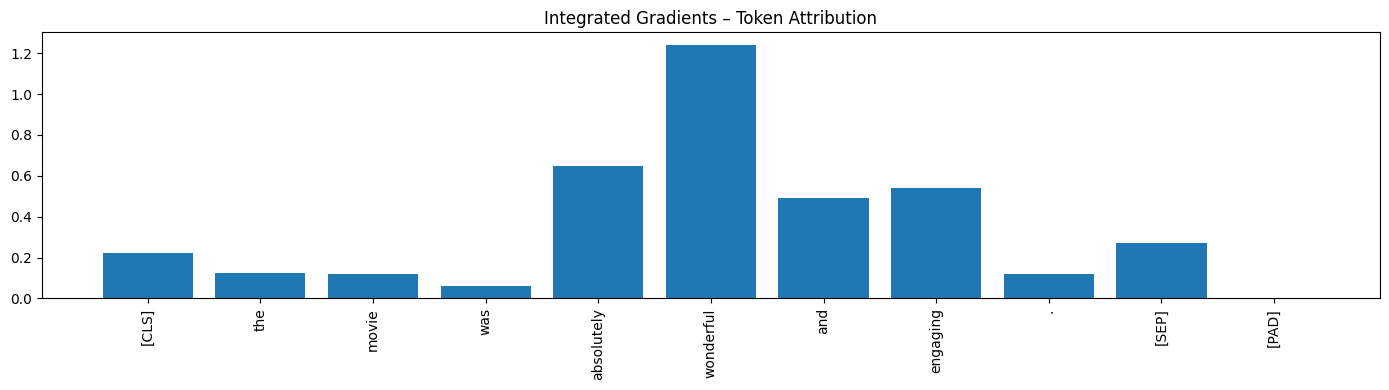

In [12]:
scores = attributions_sum[0].detach().cpu().numpy()

plt.figure(figsize=(14,4))
plt.bar(tokens, scores)
plt.xticks(rotation=90)
plt.title("Integrated Gradients – Token Attribution")
plt.tight_layout()
plt.show()


**🔹 Step 11: Saving Plots**

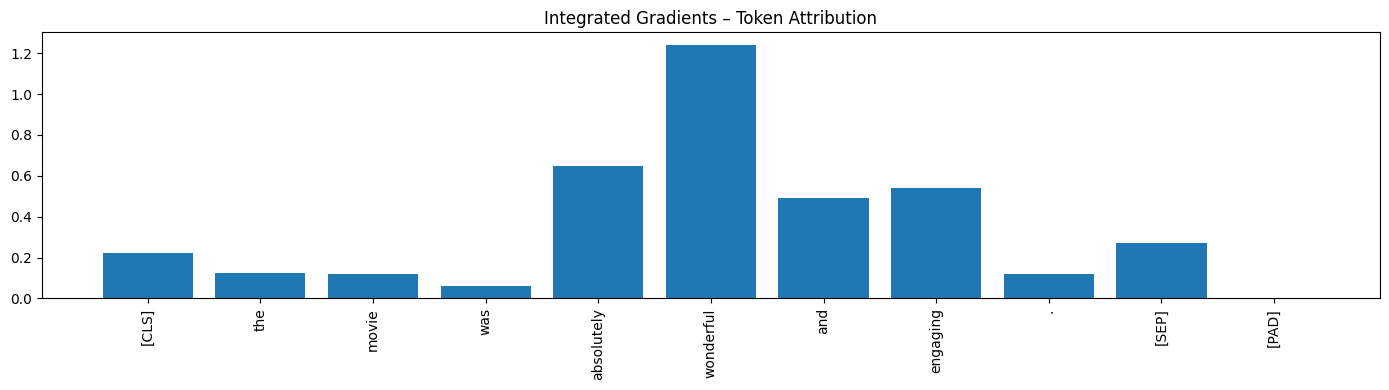

Plot saved at: /content/drive/MyDrive/ResearchModels/Paper1/plots/ig_plots/ig_example.png


In [16]:
import os

save_path = "/content/drive/MyDrive/ResearchModels/Paper1/plots/ig_plots/ig_example.png"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

plt.figure(figsize=(14,4))
plt.bar(tokens, scores)
plt.xticks(rotation=90)
plt.title("Integrated Gradients – Token Attribution")
plt.tight_layout()
plt.savefig(save_path)
plt.show()

print("Plot saved at:", save_path)